In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

In [2]:
# Load data
train_df = pd.read_csv('../data/interim/train.csv')
val_df = pd.read_csv('../data/interim/val.csv')

TARGET_COL = 'Scope_3_coverage'

print(f"Training samples: {len(train_df)}")
print(f"Features: {train_df.shape[1] - 1}")
print(f"\nTarget distribution:")
print(train_df[TARGET_COL].value_counts())

Training samples: 1129
Features: 22

Target distribution:
Scope_3_coverage
Yes              456
Not Specified    247
Partial          218
No               208
Name: count, dtype: int64


---
## 1. Data Preparation for Feature Selection

Feature selection methods require encoded features. We'll apply the encoding strategy from `encoding_strategy.md`.

In [ ]:
# Define feature groups (from encoding_strategy.md)
# NOTE: Scope_1_coverage and Scope_2_coverage are EXCLUDED due to TARGET LEAKAGE
# They are decided simultaneously with Scope_3_coverage during corporate emissions reporting

LEAKAGE_COLS = ['Scope_1_coverage', 'Scope_2_coverage']  # DO NOT USE - target leakage

ORDINAL_COLS = [
    'Published_plan', 'Private_company', 'Race_to_zero_member', 
    'Separate_removal_target', 'Historical_emissions', 'Accountability_delivery',
    'Carbon_credits', 'GHGs_covered',
    'Reporting_mechanism', 'Status_of_end_target', 'Planning_removals'
]

NOMINAL_COLS = ['Country', 'Geographic_region', 'Industry', 'End_target', 'Interim_target']

NUMERIC_COLS = ['log_revenue', 'log_employees', 'End_target_year', 'Interim_target_year']

print(f"⚠️  EXCLUDED (leakage): {LEAKAGE_COLS}")
print(f"Ordinal features: {len(ORDINAL_COLS)}")
print(f"Nominal features: {len(NOMINAL_COLS)}")
print(f"Numeric features: {len(NUMERIC_COLS)}")
print(f"Total: {len(ORDINAL_COLS) + len(NOMINAL_COLS) + len(NUMERIC_COLS)}")

Ordinal features: 13
Nominal features: 5
Numeric features: 4
Total: 22


In [ ]:
# Prepare X and y
# Drop target AND leakage columns
drop_cols = [TARGET_COL] + [c for c in LEAKAGE_COLS if c in train_df.columns]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[TARGET_COL]

X_val = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])
y_val = val_df[TARGET_COL]

print(f"Dropped columns: {drop_cols}")

# Encode target
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

print("Target classes:", label_encoder.classes_)
print("Encoded as:", list(range(len(label_encoder.classes_))))


Target classes: ['No' 'Not Specified' 'Partial' 'Yes']
Encoded as: [0, 1, 2, 3]


In [5]:
# Create preprocessor with encoding
# For feature selection, we'll use simpler encoding to keep feature names interpretable

# Ordinal encode all categorical features for MI and RFE
# (One-hot would create too many features for initial selection)
all_categorical = ORDINAL_COLS + NOMINAL_COLS

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), all_categorical),
        ('num', 'passthrough', NUMERIC_COLS)
    ],
    verbose_feature_names_out=False
)

# Fit on training data only
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)

# Get feature names
feature_names = all_categorical + NUMERIC_COLS

print(f"Encoded shape: {X_train_enc.shape}")
print(f"Feature names: {feature_names}")

Encoded shape: (1129, 22)
Feature names: ['Published_plan', 'Private_company', 'Race_to_zero_member', 'Separate_removal_target', 'Historical_emissions', 'Accountability_delivery', 'Scope_1_coverage', 'Scope_2_coverage', 'Carbon_credits', 'GHGs_covered', 'Reporting_mechanism', 'Status_of_end_target', 'Planning_removals', 'Country', 'Geographic_region', 'Industry', 'End_target', 'Interim_target', 'log_revenue', 'log_employees', 'End_target_year', 'Interim_target_year']


---
## 2. Filter Method: Mutual Information

Mutual Information (MI) measures the dependency between each feature and the target. It captures non-linear relationships, making it suitable for our mixed feature types.

In [6]:
# Calculate Mutual Information scores for all features
mi_scores = mutual_info_classif(X_train_enc, y_train_enc, random_state=SEED)

# Create dataframe of scores
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("=== MUTUAL INFORMATION SCORES ===")
print(mi_df.to_string(index=False))

=== MUTUAL INFORMATION SCORES ===
                Feature  MI_Score
       Scope_1_coverage  0.276222
       Scope_2_coverage  0.237351
             End_target  0.165520
         Published_plan  0.098981
                Country  0.090311
         Interim_target  0.063860
    Race_to_zero_member  0.051514
           GHGs_covered  0.041869
Accountability_delivery  0.033537
    Reporting_mechanism  0.027703
        End_target_year  0.027689
   Status_of_end_target  0.021387
      Geographic_region  0.021236
               Industry  0.019202
    Interim_target_year  0.018136
   Historical_emissions  0.016192
      Planning_removals  0.014576
        Private_company  0.009968
         Carbon_credits  0.000340
            log_revenue  0.000096
          log_employees  0.000000
Separate_removal_target  0.000000


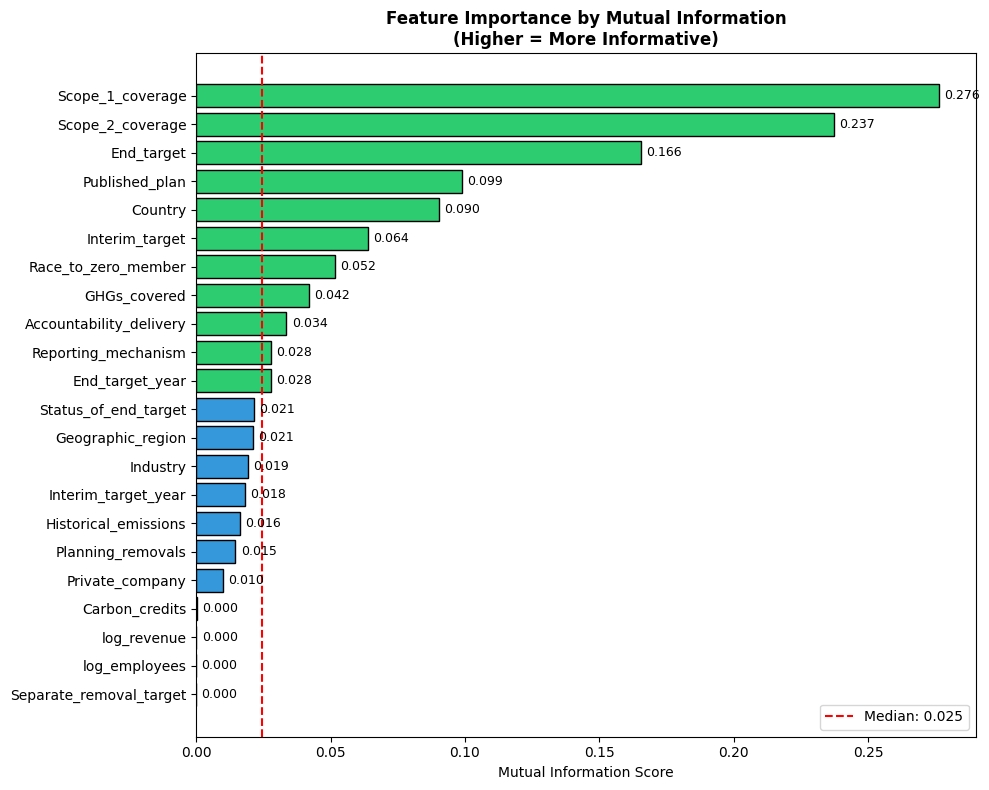


=== TOP 10 FEATURES (Mutual Information) ===
 1. Scope_1_coverage
 2. Scope_2_coverage
 3. End_target
 4. Published_plan
 5. Country
 6. Interim_target
 7. Race_to_zero_member
 8. GHGs_covered
 9. Accountability_delivery
10. Reporting_mechanism


In [7]:
# Visualize MI scores
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2ecc71' if score > mi_df['MI_Score'].median() else '#3498db' for score in mi_df['MI_Score']]

bars = ax.barh(mi_df['Feature'], mi_df['MI_Score'], color=colors, edgecolor='black')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Importance by Mutual Information\n(Higher = More Informative)', fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, score in zip(bars, mi_df['MI_Score']):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2, f'{score:.3f}', 
            va='center', fontsize=9)

# Add median line
ax.axvline(mi_df['MI_Score'].median(), color='red', linestyle='--', 
           label=f'Median: {mi_df["MI_Score"].median():.3f}')
ax.legend()

plt.tight_layout()
plt.savefig('../other_files/feature_selection_mi_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Select top 10 features by MI
top_10_mi = mi_df.head(10)['Feature'].tolist()
print(f"\n=== TOP 10 FEATURES (Mutual Information) ===")
for i, feat in enumerate(top_10_mi, 1):
    print(f"{i:2}. {feat}")

---
## 3. Wrapper Method: Recursive Feature Elimination (RFE)

RFE uses a model to iteratively remove the weakest features. We'll use Logistic Regression as the base estimator.

In [8]:
# RFE with Logistic Regression
base_model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

rfe = RFE(estimator=base_model, n_features_to_select=10, step=1)
rfe.fit(X_train_enc, y_train_enc)

# Get selected features
rfe_selected = [feat for feat, selected in zip(feature_names, rfe.support_) if selected]
rfe_ranking = pd.DataFrame({
    'Feature': feature_names,
    'RFE_Rank': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('RFE_Rank')

print("=== RFE RANKING (Logistic Regression) ===")
print(rfe_ranking.to_string(index=False))

print(f"\n=== TOP 10 FEATURES (RFE) ===")
for i, feat in enumerate(rfe_selected, 1):
    print(f"{i:2}. {feat}")

=== RFE RANKING (Logistic Regression) ===
                Feature  RFE_Rank  Selected
         Published_plan         1      True
   Status_of_end_target         1      True
           GHGs_covered         1      True
       Scope_2_coverage         1      True
       Scope_1_coverage         1      True
    Reporting_mechanism         1      True
   Historical_emissions         1      True
Separate_removal_target         1      True
    Race_to_zero_member         1      True
        Private_company         1      True
         Carbon_credits         2     False
         Interim_target         3     False
Accountability_delivery         4     False
      Geographic_region         5     False
            log_revenue         6     False
      Planning_removals         7     False
             End_target         8     False
               Industry         9     False
          log_employees        10     False
    Interim_target_year        11     False
        End_target_year        12 

---
## 4. Embedded Method: Random Forest Feature Importance

Tree-based models provide built-in feature importance based on how much each feature contributes to reducing impurity (Gini importance).

In [9]:
# Train Random Forest for feature importance
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=SEED,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_enc, y_train_enc)

# Get feature importances
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("=== RANDOM FOREST FEATURE IMPORTANCE ===")
print(rf_importance.to_string(index=False))

# Top 10 by RF
top_10_rf = rf_importance.head(10)['Feature'].tolist()
print(f"\n=== TOP 10 FEATURES (Random Forest) ===")
for i, feat in enumerate(top_10_rf, 1):
    print(f"{i:2}. {feat}")

=== RANDOM FOREST FEATURE IMPORTANCE ===
                Feature  RF_Importance
       Scope_2_coverage       0.137356
       Scope_1_coverage       0.101525
          log_employees       0.086573
            log_revenue       0.085317
             End_target       0.065107
                Country       0.061414
        End_target_year       0.058531
               Industry       0.047648
      Planning_removals       0.039709
      Geographic_region       0.039589
         Interim_target       0.037651
    Race_to_zero_member       0.036988
Accountability_delivery       0.035055
           GHGs_covered       0.034984
         Carbon_credits       0.028662
         Published_plan       0.028299
    Interim_target_year       0.026381
   Status_of_end_target       0.015779
    Reporting_mechanism       0.011284
   Historical_emissions       0.009196
Separate_removal_target       0.007364
        Private_company       0.005590

=== TOP 10 FEATURES (Random Forest) ===
 1. Scope_2_coverage


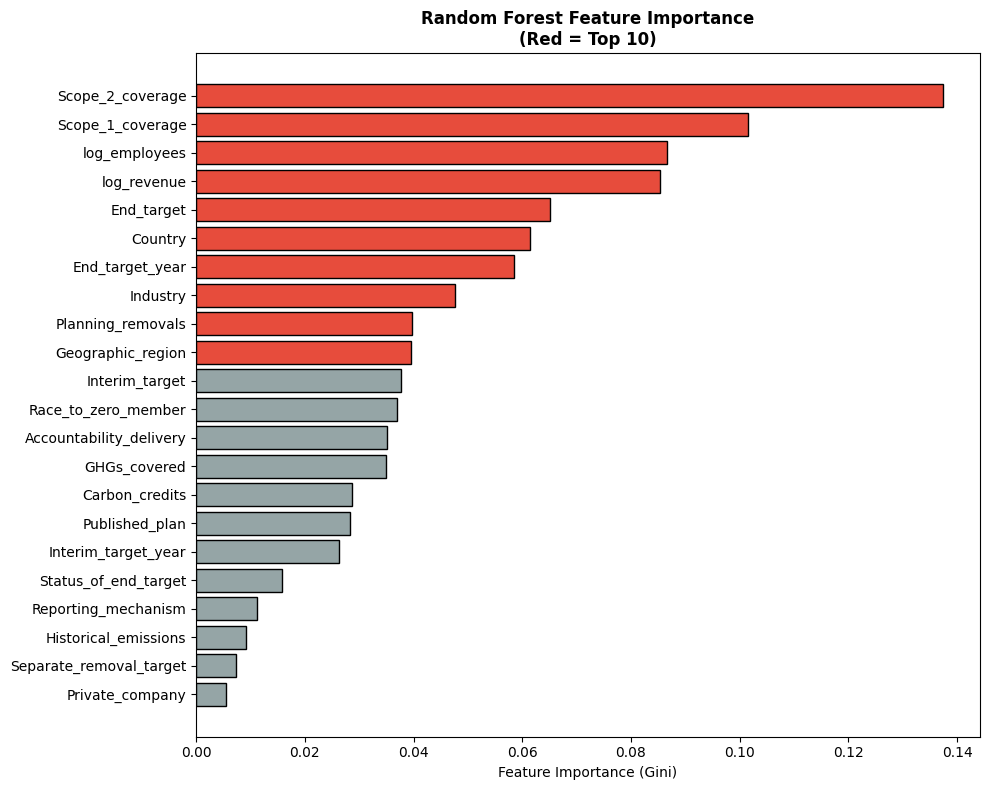

In [10]:
# Visualize RF importance
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if feat in top_10_rf else '#95a5a6' for feat in rf_importance['Feature']]

bars = ax.barh(rf_importance['Feature'], rf_importance['RF_Importance'], color=colors, edgecolor='black')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance\n(Red = Top 10)', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../other_files/feature_selection_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Method Comparison: Overlap & Differences

In [11]:
# Compare selections across methods
mi_set = set(top_10_mi)
rfe_set = set(rfe_selected)
rf_set = set(top_10_rf)

# Calculate overlaps
all_three = mi_set & rfe_set & rf_set
mi_rfe = mi_set & rfe_set
mi_rf = mi_set & rf_set
rfe_rf = rfe_set & rf_set

print("=== FEATURE SELECTION COMPARISON ===")
print(f"\nFeatures selected by ALL THREE methods ({len(all_three)}):")
for feat in sorted(all_three):
    print(f"  ✓ {feat}")

print(f"\nFeatures in MI + RFE only ({len(mi_rfe - all_three)}):")
for feat in sorted(mi_rfe - all_three):
    print(f"  • {feat}")

print(f"\nFeatures in MI + RF only ({len(mi_rf - all_three)}):")
for feat in sorted(mi_rf - all_three):
    print(f"  • {feat}")

print(f"\nFeatures in RFE + RF only ({len(rfe_rf - all_three)}):")
for feat in sorted(rfe_rf - all_three):
    print(f"  • {feat}")

=== FEATURE SELECTION COMPARISON ===

Features selected by ALL THREE methods (2):
  ✓ Scope_1_coverage
  ✓ Scope_2_coverage

Features in MI + RFE only (4):
  • GHGs_covered
  • Published_plan
  • Race_to_zero_member
  • Reporting_mechanism

Features in MI + RF only (2):
  • Country
  • End_target

Features in RFE + RF only (0):


In [12]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Top10': [feat in mi_set for feat in feature_names],
    'RFE_Top10': [feat in rfe_set for feat in feature_names],
    'RF_Top10': [feat in rf_set for feat in feature_names]
})

comparison_df['Methods_Selected'] = comparison_df[['MI_Top10', 'RFE_Top10', 'RF_Top10']].sum(axis=1)
comparison_df = comparison_df.sort_values('Methods_Selected', ascending=False)

print("=== FULL COMPARISON TABLE ===")
print(comparison_df.to_string(index=False))

=== FULL COMPARISON TABLE ===
                Feature  MI_Top10  RFE_Top10  RF_Top10  Methods_Selected
       Scope_1_coverage      True       True      True                 3
       Scope_2_coverage      True       True      True                 3
         Published_plan      True       True     False                 2
    Race_to_zero_member      True       True     False                 2
           GHGs_covered      True       True     False                 2
    Reporting_mechanism      True       True     False                 2
             End_target      True      False      True                 2
                Country      True      False      True                 2
      Geographic_region     False      False      True                 1
        End_target_year     False      False      True                 1
          log_employees     False      False      True                 1
            log_revenue     False      False      True                 1
         Interim_targ

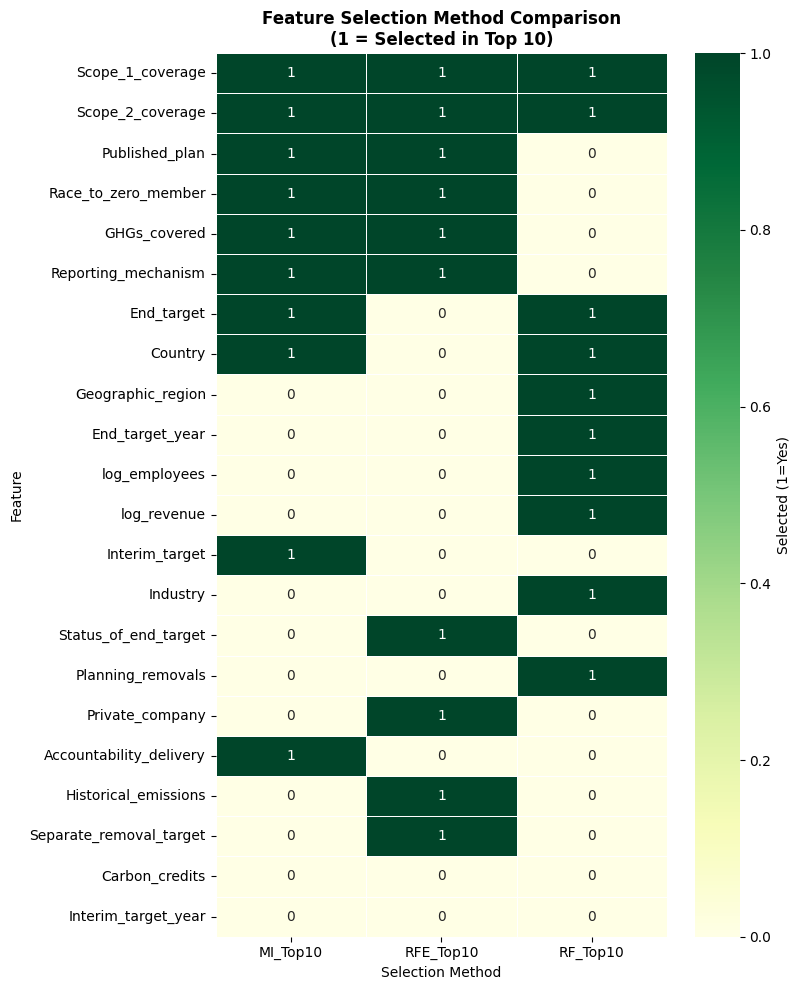

In [13]:
# Visualize overlap with a heatmap
fig, ax = plt.subplots(figsize=(8, 10))

# Prepare data for heatmap
heatmap_data = comparison_df.set_index('Feature')[['MI_Top10', 'RFE_Top10', 'RF_Top10']].astype(int)

sns.heatmap(heatmap_data, annot=True, cmap='YlGn', cbar_kws={'label': 'Selected (1=Yes)'}, 
            ax=ax, linewidths=0.5)
ax.set_title('Feature Selection Method Comparison\n(1 = Selected in Top 10)', fontweight='bold')
ax.set_xlabel('Selection Method')

plt.tight_layout()
plt.savefig('../other_files/feature_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Analysis of Differences

Let's analyze why methods might disagree on certain features.

In [14]:
# Features selected by only ONE method
only_mi = mi_set - rfe_set - rf_set
only_rfe = rfe_set - mi_set - rf_set
only_rf = rf_set - mi_set - rfe_set

print("=== FEATURES UNIQUE TO EACH METHOD ===")
print(f"\nOnly in Mutual Information ({len(only_mi)}):")
for feat in only_mi:
    print(f"  → {feat}")
    print(f"    Possible reason: Non-linear relationship with target that linear models miss")

print(f"\nOnly in RFE ({len(only_rfe)}):")
for feat in only_rfe:
    print(f"  → {feat}")
    print(f"    Possible reason: Linear predictive power in combination with other features")

print(f"\nOnly in Random Forest ({len(only_rf)}):")
for feat in only_rf:
    print(f"  → {feat}")
    print(f"    Possible reason: Important for tree splits; interaction effects")

=== FEATURES UNIQUE TO EACH METHOD ===

Only in Mutual Information (2):
  → Accountability_delivery
    Possible reason: Non-linear relationship with target that linear models miss
  → Interim_target
    Possible reason: Non-linear relationship with target that linear models miss

Only in RFE (4):
  → Historical_emissions
    Possible reason: Linear predictive power in combination with other features
  → Separate_removal_target
    Possible reason: Linear predictive power in combination with other features
  → Status_of_end_target
    Possible reason: Linear predictive power in combination with other features
  → Private_company
    Possible reason: Linear predictive power in combination with other features

Only in Random Forest (6):
  → Industry
    Possible reason: Important for tree splits; interaction effects
  → Geographic_region
    Possible reason: Important for tree splits; interaction effects
  → log_employees
    Possible reason: Important for tree splits; interaction effect

---
## 7. Variance Threshold Check

Check if any features have near-zero variance (little information).

In [15]:
# Calculate variance for each feature
variance_df = pd.DataFrame({
    'Feature': feature_names,
    'Variance': np.var(X_train_enc, axis=0)
}).sort_values('Variance')

print("=== FEATURE VARIANCE (Lowest First) ===")
print(variance_df.to_string(index=False))

# Flag low variance features (threshold = 0.1)
low_var = variance_df[variance_df['Variance'] < 0.1]
if len(low_var) > 0:
    print(f"\n⚠️  Low variance features (< 0.1):")
    print(low_var.to_string(index=False))
else:
    print(f"\n✅ No features with variance < 0.1")

=== FEATURE VARIANCE (Lowest First) ===
                Feature   Variance
        Private_company   0.035817
Separate_removal_target   0.058933
   Historical_emissions   0.074106
    Race_to_zero_member   0.172894
       Scope_1_coverage   0.194364
       Scope_2_coverage   0.202256
   Status_of_end_target   0.204723
         Published_plan   0.227460
    Reporting_mechanism   0.265104
         Carbon_credits   0.371300
Accountability_delivery   0.395597
           GHGs_covered   0.767305
            log_revenue   1.000000
          log_employees   1.000000
         Interim_target   1.338661
      Planning_removals   1.980779
      Geographic_region   2.481676
             End_target   7.075522
    Interim_target_year   7.475994
               Industry  10.659991
        End_target_year  88.619191
                Country 299.337417

⚠️  Low variance features (< 0.1):
                Feature  Variance
        Private_company  0.035817
Separate_removal_target  0.058933
   Historical_emi

---
## 8. Final Feature Selection Recommendations

In [16]:
# Final recommendations based on analysis
# Features selected by 2+ methods are high-confidence
high_confidence = comparison_df[comparison_df['Methods_Selected'] >= 2]['Feature'].tolist()
medium_confidence = comparison_df[comparison_df['Methods_Selected'] == 1]['Feature'].tolist()
low_confidence = comparison_df[comparison_df['Methods_Selected'] == 0]['Feature'].tolist()

print("="*60)
print("FEATURE SELECTION RECOMMENDATIONS")
print("="*60)

print(f"\n🟢 HIGH CONFIDENCE - Keep & Engineer ({len(high_confidence)} features):")
print("   Features selected by 2+ methods")
for feat in high_confidence:
    methods = []
    if feat in mi_set: methods.append('MI')
    if feat in rfe_set: methods.append('RFE')
    if feat in rf_set: methods.append('RF')
    print(f"   • {feat} [{', '.join(methods)}]")

print(f"\n🟡 MEDIUM CONFIDENCE - Keep for Now ({len(medium_confidence)} features):")
print("   Features selected by 1 method only")
for feat in medium_confidence:
    methods = []
    if feat in mi_set: methods.append('MI')
    if feat in rfe_set: methods.append('RFE')
    if feat in rf_set: methods.append('RF')
    print(f"   • {feat} [{', '.join(methods)}]")

print(f"\n🔴 LOW CONFIDENCE - Consider Dropping ({len(low_confidence)} features):")
print("   Not selected by any method")
for feat in low_confidence:
    print(f"   • {feat}")

FEATURE SELECTION RECOMMENDATIONS

🟢 HIGH CONFIDENCE - Keep & Engineer (8 features):
   Features selected by 2+ methods
   • Scope_1_coverage [MI, RFE, RF]
   • Scope_2_coverage [MI, RFE, RF]
   • Published_plan [MI, RFE]
   • Race_to_zero_member [MI, RFE]
   • GHGs_covered [MI, RFE]
   • Reporting_mechanism [MI, RFE]
   • End_target [MI, RF]
   • Country [MI, RF]

🟡 MEDIUM CONFIDENCE - Keep for Now (12 features):
   Features selected by 1 method only
   • Geographic_region [RF]
   • End_target_year [RF]
   • log_employees [RF]
   • log_revenue [RF]
   • Interim_target [MI]
   • Industry [RF]
   • Status_of_end_target [RFE]
   • Planning_removals [RF]
   • Private_company [RFE]
   • Accountability_delivery [MI]
   • Historical_emissions [RFE]
   • Separate_removal_target [RFE]

🔴 LOW CONFIDENCE - Consider Dropping (2 features):
   Not selected by any method
   • Carbon_credits
   • Interim_target_year


In [17]:
# Summary table for documentation
summary_data = []
for feat in feature_names:
    mi_rank = mi_df[mi_df['Feature'] == feat].index[0] + 1 if feat in mi_df['Feature'].values else None
    rfe_rank = rfe_ranking[rfe_ranking['Feature'] == feat]['RFE_Rank'].values[0]
    rf_rank = rf_importance[rf_importance['Feature'] == feat].index[0] + 1 if feat in rf_importance['Feature'].values else None
    
    if feat in high_confidence:
        decision = 'KEEP'
    elif feat in medium_confidence:
        decision = 'KEEP (monitor)'
    else:
        decision = 'DROP candidate'
    
    summary_data.append({
        'Feature': feat,
        'MI_Rank': mi_df.index[mi_df['Feature'] == feat].tolist()[0] + 1,
        'RFE_Rank': rfe_rank,
        'RF_Rank': rf_importance.index[rf_importance['Feature'] == feat].tolist()[0] + 1,
        'Decision': decision
    })

summary_df = pd.DataFrame(summary_data).sort_values('MI_Rank')
print("\n=== FEATURE SELECTION SUMMARY TABLE ===")
print(summary_df.to_string(index=False))


=== FEATURE SELECTION SUMMARY TABLE ===
                Feature  MI_Rank  RFE_Rank  RF_Rank       Decision
         Published_plan        1         1        1           KEEP
        Private_company        2         1        2 KEEP (monitor)
    Race_to_zero_member        3         1        3           KEEP
Separate_removal_target        4         1        4 KEEP (monitor)
   Historical_emissions        5         1        5 KEEP (monitor)
Accountability_delivery        6         4        6 KEEP (monitor)
       Scope_1_coverage        7         1        7           KEEP
       Scope_2_coverage        8         1        8           KEEP
         Carbon_credits        9         2        9 DROP candidate
           GHGs_covered       10         1       10           KEEP
    Reporting_mechanism       11         1       11           KEEP
   Status_of_end_target       12         1       12 KEEP (monitor)
      Planning_removals       13         7       13 KEEP (monitor)
                Count

---
## 9. Conclusions & Next Steps

### Key Findings

| Method | Strengths | Weaknesses |
|--------|-----------|------------|
| **Mutual Information** | Captures non-linear relationships | Doesn't consider feature interactions |
| **RFE (Logistic Regression)** | Considers feature combinations | Assumes linear relationships |
| **Random Forest Importance** | Captures interactions & non-linearity | Can be biased toward high-cardinality features |

### Recommendations

1. **Keep all HIGH CONFIDENCE features** - consistently important across methods
2. **Monitor MEDIUM CONFIDENCE features** - may become important with interactions
3. **Test dropping LOW CONFIDENCE features** - validate with cross-validation
4. **Create interaction features** for top features (e.g., Industry × End_target)

### For Capstone
- Document feature selection rationale in final report
- Include comparison visualizations
- Validate final feature set with holdout performance

In [18]:
# Save results for modeling pipeline
results = {
    'high_confidence_features': high_confidence,
    'medium_confidence_features': medium_confidence,
    'low_confidence_features': low_confidence,
    'mi_scores': mi_df.to_dict('records'),
    'rf_importance': rf_importance.to_dict('records')
}

import json
with open('../other_files/feature_selection_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✅ Results saved to: other_files/feature_selection_results.json")

✅ Results saved to: other_files/feature_selection_results.json
